In [1]:
import pandas as pd
# Import the packages and load the Excel csdb file

import tkinter as tk
from tkinter import filedialog

root = tk.Tk()
root.withdraw()

file = filedialog.askopenfilename(
    title="Select the CSDB Excel file",
    filetypes=[("Excel files", "*.xlsx")]
)

print(file)

C:/Users/User/Downloads/csdb-main.xlsx


In [18]:
# Load the Excel file and the "All Years" tab:
excel = pd.ExcelFile(file)
excel.sheet_names

df = pd.read_excel(file, sheet_name="All Years")

In [19]:
# 1. Data overview:
print("Rows:", len(df))
print("Columns:", len(df.columns))
print("Period:", df["year"].min(), "-", df["year"].max())

Rows: 3553
Columns: 45
Period: 2023.0 - 2026.0


In [4]:
# 2. Seizures over time:
seizures_year = df["year"].value_counts().sort_index()

seizures_year

year
2023.0     600
2024.0     846
2025.0    1413
2026.0     693
Name: count, dtype: int64

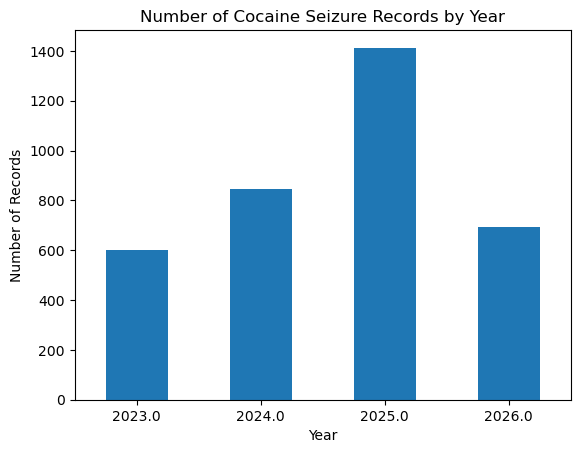

In [5]:
# 2.1: Graphic visualization:
import matplotlib.pyplot as plt
seizures_year.plot(
    kind="bar",
    title="Number of Cocaine Seizure Records by Year"
)

plt.xlabel("Year")
plt.ylabel("Number of Records")
plt.xticks(rotation=0)
plt.show()

In [6]:
# 3. Seizures by region:
print("REGIONS")
print(df["region"].value_counts())

print("\nCOUNTRIES")
print(df["country"].value_counts())

REGIONS
region
South America      1913
Europe              717
Central America     372
Caribbean           277
North America       157
Africa               76
Asia                 21
Oceania              12
Global                7
Atlantic              1
Name: count, dtype: int64

COUNTRIES
country
Brazil                            518
Colombia                          512
Argentina                         248
Ecuador                           236
Spain                             203
                                 ... 
Guinea-Bissau                       1
St. Vincent and the Grenadines      1
Mozambique                          1
Croatia (Hrvatska)                  1
Fiji                                1
Name: count, Length: 110, dtype: int64


In [7]:
print(df.shape)
print(df["region"].unique())
print(df["country"].nunique())

(3553, 45)
['Europe' 'Central America' 'South America' 'Caribbean' 'Africa'
 'North America' 'Oceania' 'Asia' 'Global' 'Atlantic']
110


In [8]:
df["quantity_unit"].value_counts(dropna=False)

# Convert quantity to numeric
df["quantity_numeric"] = pd.to_numeric(
    df["quantity"].astype(str).str.replace(",", "", regex=False),
    errors="coerce"
)

# New standardized quantity variable
df["quantity_kg"] = float("nan")

# Already in kilograms
df.loc[df["quantity_unit"] == "Kilogram", "quantity_kg"] = \
    df["quantity_numeric"]

# Pounds (lbs) -> kilograms
df.loc[df["quantity_unit"] == "Pounds (lbs)", "quantity_kg"] = \
    df["quantity_numeric"] * 0.453592

# Grams -> kilograms
df.loc[df["quantity_unit"] == "Gram", "quantity_kg"] = \
    df["quantity_numeric"] / 1000

In [9]:
df["quantity_kg"].describe()

count    3.073000e+03
mean     3.263199e+03
std      5.364011e+04
min      1.000000e-03
25%      5.000000e+01
50%      2.570000e+02
75%      8.980000e+02
max      2.600000e+06
Name: quantity_kg, dtype: float64

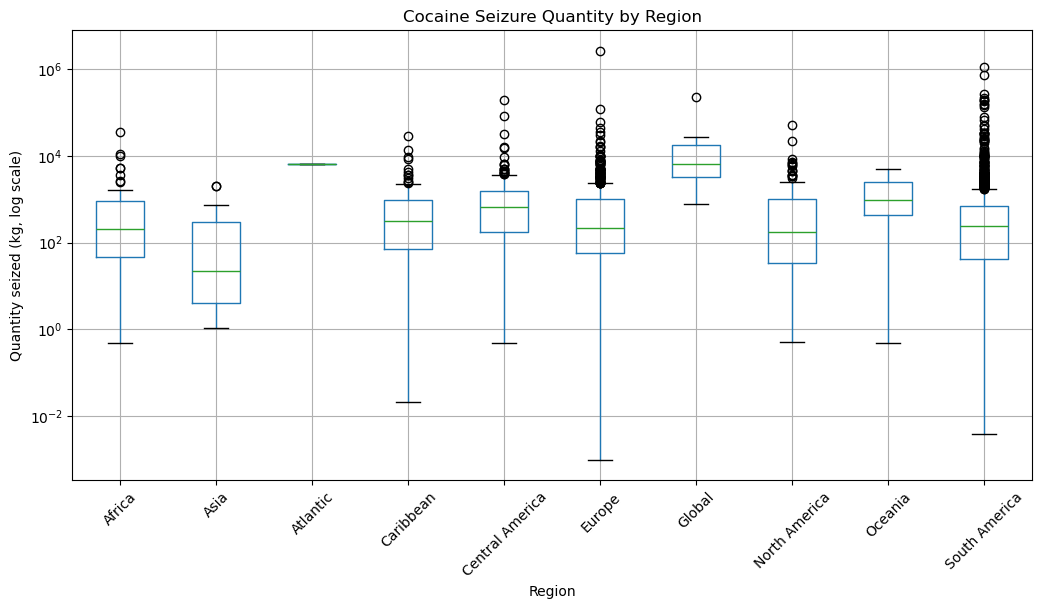

In [10]:
# Relation between: quantity x region

import matplotlib.pyplot as plt

data_plot = df.dropna(subset=["quantity_kg", "region"])

data_plot.boxplot(
    column="quantity_kg",
    by="region",
    figsize=(12, 6)
)

plt.yscale("log")
plt.title("Cocaine Seizure Quantity by Region")
plt.suptitle("")
plt.xlabel("Region")
plt.ylabel("Quantity seized (kg, log scale)")
plt.xticks(rotation=45)
plt.show()

In [11]:
region_summary = (
    df.dropna(subset=["quantity_kg", "region"])
      .groupby("region")["quantity_kg"]
      .agg(
          N="count",
          Mean="mean",
          Median="median",
          SD="std",
          Min="min",
          Max="max"
      )
      .round(2)
      .sort_values("Median", ascending=False)
)

region_summary

,N,Mean,Median,SD,Min,Max
region,,,,,,
Global,7,39172.26,6600.00,82410.90,760.00,225000.00
Atlantic,1,6500.00,6500.00,NaN,6500.00,6500.00
Oceania,11,1607.77,932.00,1698.67,0.49,4870.00
Central America,182,2926.01,659.00,15310.54,0.50,188000.00
Caribbean,203,934.80,318.00,2406.55,0.02,28004.77
South America,1739,2944.18,242.00,33662.71,0.00,1080800.00
Europe,697,5150.22,222.00,98601.74,0.00,2600000.00
Africa,74,1323.31,207.50,4382.59,0.50,35000.00
North America,138,1399.58,176.75,4822.39,0.50,50000.00


In [12]:
# 4. Modus operandi
df["modus_operandi"].value_counts(dropna=False)

df["sub_modus_operandi"].value_counts(dropna=False).head(20)

sub_modus_operandi
NaN                               1530
Container                          436
Other (explain in Description)     289
Truck                              218
Vehicle                            182
Car                                134
Go-fast boat                       102
Storage Site                        97
Backpack/Bag/Suitcase               75
Cargo Ship                          51
Private Boat                        45
House/Storage Site                  43
Body Carry                          38
Bus                                 38
Commercial flight                   35
Go-Fast                             22
Parcel/Courier Service              22
Commercial Vessel                   22
Human courier                       21
Fishing Vessel                      18
Name: count, dtype: int64

In [13]:
# Relation between seizure quantity and modus operandi
df["modus_operandi"].value_counts(dropna=False)

modus_operandi
Land        1651
Maritime    1285
NaN          303
Air          278
River         19
Multiple      17
Name: count, dtype: int64

In [14]:
modus_summary = (
    df.dropna(subset=["modus_operandi", "quantity_kg"])
      .groupby("modus_operandi")["quantity_kg"]
      .agg(N="count", Mean="mean", Median="median", SD="std")
      .round(2)
      .sort_values("Median", ascending=False)
)

modus_summary

,N,Mean,Median,SD
modus_operandi,,,,
Multiple,14,28730.81,2077.00,58896.28
Maritime,1120,3307.80,732.50,34315.77
Land,1411,3147.86,100.00,72213.37
River,15,729.13,91.75,1671.43
Air,246,283.70,16.50,1455.32


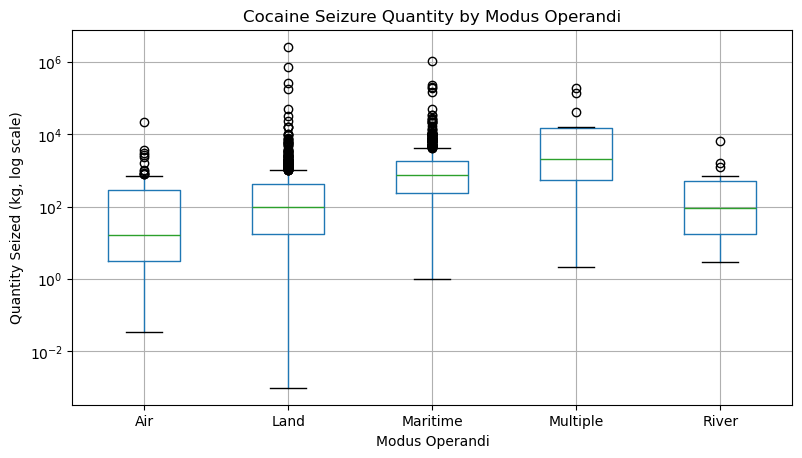

In [15]:
# 4.1: Graphic visualization:
df.dropna(subset=["modus_operandi", "quantity_kg"]).boxplot(
    column="quantity_kg",
    by="modus_operandi",
    figsize=(9,5)
)

plt.yscale("log")
plt.title("Cocaine Seizure Quantity by Modus Operandi")
plt.suptitle("")
plt.xlabel("Modus Operandi")
plt.ylabel("Quantity Seized (kg, log scale)")
plt.show()

In [16]:
# 5. Routes
route_coverage = df[
    ["origin_country",
     "transit_1_country",
     "transit_2_country",
     "destination_1_country",
     "destination_2_country"]
].notna().sum()

route_coverage

origin_country            522
transit_1_country        1506
transit_2_country         340
destination_1_country     800
destination_2_country      44
dtype: int64

In [17]:
# Origin country; transit country (1); destination country (1)
route_cols = [
    "origin_country",
    "transit_1_country",
    "destination_1_country"
]

for col in route_cols:
    print(f"\n{col.upper()}")
    print(df[col].value_counts().head(10))


ORIGIN_COUNTRY
origin_country
Colombia              271
Bolivia               135
Peru                   43
Ecuador                27
Honduras               14
Brazil                  6
Guatemala               5
Dominican Republic      3
Paraguay                2
Mexico                  2
Name: count, dtype: int64

TRANSIT_1_COUNTRY
transit_1_country
Brazil                239
Ecuador               186
Colombia              116
Panama                 89
Argentina              83
Spain                  78
Dominican Republic     74
Mexico                 59
Bolivia                40
Costa Rica             37
Name: count, dtype: int64

DESTINATION_1_COUNTRY
destination_1_country
Spain            128
Belgium           87
Netherlands       85
United States     58
Brazil            52
France            44
Argentina         42
Italy             35
Germany           27
Portugal          20
Name: count, dtype: int64
